In [111]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

# Mode in reflection

Here we use a non-RWA model of a driven linear mode.

We can sweep a variety of mode parameters and drive parameters.

In particular, we adjust $\kappa_{int}$, $\kappa_{ext}$, and the Kerr nonlinearity $K$. We sweep the drive frequency and power. For a finite Kerr, we see an increasingly nonlinear response for larger drive powers.

In [112]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('sqrtka_ext', np.sqrt(100e6*2*pi)) # in MHz
sim.add_param('ka_int', 0e6*2*pi) # in MHz
# sim.add_param('K', 1000e6 * 2 * np.pi)
sim.add_param('amplR',  1e6)
sim.add_param('wa', 5.0e9*2*pi)
# sim.add_paramsweep('wa', 4.99e9*2*pi, 5.01e9*2*pi, 101)  #this simulates a slow dephasing effect
sim.add_paramsweep('wR', 4.5e9 * 2 * np.pi, 5.5e9 * 2 * np.pi, 101, is_excitation=True)
sim.add_param('rampR', 10e-9)
sim.add_param('startR', -20e-9)
sim.add_param('stopR', 1000e-9)
sim.add_param('phaseR', 0)

Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')

sim.add_EOM('a', '-1j*wa*a - ain*sqrtka_ext - (sqrtka_ext**2 + ka_int)/2*a')
sim.add_drive_EOM('ain', Rpulse)
sim.set_solve_type('decimate')

sim.specify_time(pts_per_cycle=40, num_cycles=500, d_factor=1)

sim.validate(print_result=False)

Recent change to specify_time(), check implementation
Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


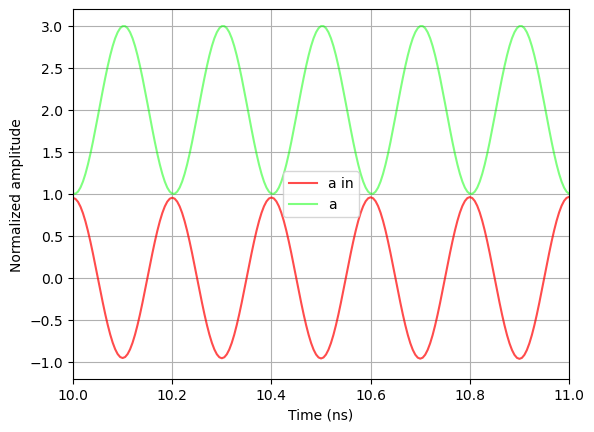

In [113]:
x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='a in')
plt.plot(t*1e9, x[2,:]/np.max(x[2,:])+2,color=(0,1,0,0.5),label='a')
plt.xlim([10,11])
# plt.plot(t*1e9, x[3,:],color=(0,0,0,0.5),label='a')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()
plt.show()

In [114]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|██████████████████████████████████████████████████████████████████████████| 20000/20000 [00:11<00:00, 1747.18it/s]

 
...finished GPU solve!


In [105]:
Id = I.copy()
Qd = Q.copy()
td = t.copy()

ain = Id[2,:]+1j*Qd[2,:]
a = Id[0,:]+1j*Qd[0,:]

aout = ain + sim.param_dict['sqrtka_ext']*a

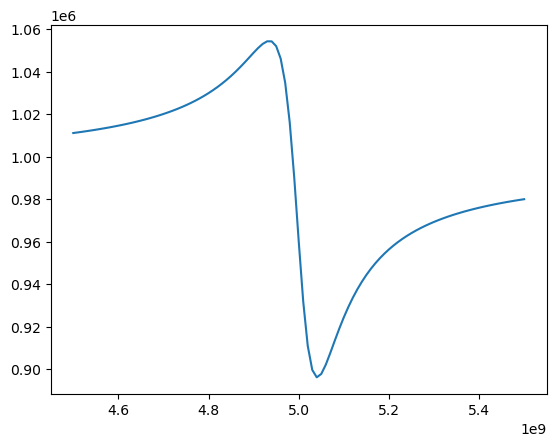

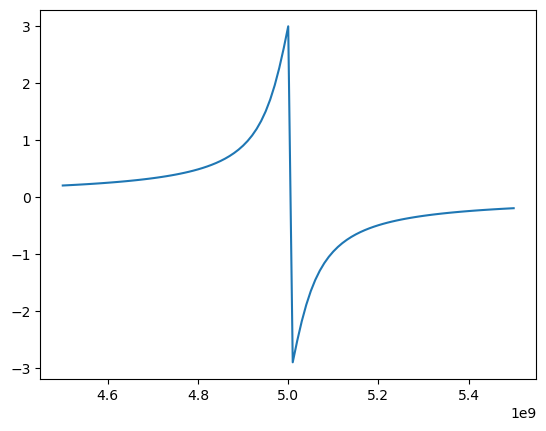

In [109]:
S11_mag = np.mean(np.abs(aout),axis=1)
S11_phase = np.angle(aout[:,-1]/ain[:,-1])

wR = sim.paramsweep_dict['wR']/(2*np.pi)

plt.plot(wR, S11_mag)
plt.show()
plt.plot(wR, S11_phase)
plt.show()